# 02a · Segmentation with brightfield

For samples with inclusion bodies (IBs) and a transmitted-light z-stack:

1. **IBs** from the fluorescence intensity image (difference of Gaussians
   and Otsu threshold);
2. **cells** from the brightfield stack with Cellpose-SAM;
3. **cytosol** = cells minus the IBs and a halo around them.

Input are the images written by notebook 01. Masks are written to
`masks_auto/<sample>_ib_masks/` and `masks_auto/<sample>_cell_masks/`, with
one overview (`<sample>_bf_overview.png`) per sample. Images whose brightfield stack does not match
the FLIM field of view are skipped; segment those with notebook 02b.

In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt
from skimage import io
from skimage.segmentation import expand_labels

from cellpose import models

import flim_fret_data_processing.config as config
from flim_fret_data_processing.helpers import (
    check_bf_registration,
    index_samples,
    keep_solid_pieces,
    overlay_labels,
    save_labels,
    save_overview,
    segment_ibs,
)

## Inputs

In [2]:
root_dir      = config.REPO_DIR
raw_dir       = config.RAW_DIR          # for the .msr metadata
intensity_dir = config.INTENSITY_DIR    # <session>/<sample>_export and <sample>_bf
output_dir    = config.MASKS_AUTO_DIR

# Sample folders to segment.
samples = ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '12', '13',
           '15', '16', '19', '21', '22', '23', '24', '25']

z_planes = 5   # planes per brightfield stack / FLIM z-stack

# --- inclusion bodies ---
ib_dog_sigma_small = 1     # px; suppresses shot noise, keep well below the IB radius
ib_dog_sigma_large = 3     # px; background scale, raise to keep large IBs whole
ib_min_size        = 20    # px; smallest accepted IB
ib_expand_distance = 1.8   # px the saved IB label is grown by, to cover its edge pixels
ib_halo_distance   = 7     # px around each IB excluded from the cytosol mask

# --- cells (Cellpose-SAM on the brightfield projection) ---
cellpose_flow_threshold     = 0.4
cellpose_cellprob_threshold = 0
use_gpu = __import__("torch").cuda.is_available()

# --- cytosol: pieces smaller or thinner than this are dropped ---
cell_min_area           = 10    # px
cell_min_half_thickness = 1.5   # px

## Load the fluorescence / brightfield pairs

A pair is accepted only if the `.msr` metadata confirm that the brightfield
stack and the FLIM scan share the same stage position and pixel grid.

In [3]:
sample_index = index_samples(raw_dir)

pairs = []      # (sample, image base name, fluorescence image, brightfield stack)
rejected = []

for sample in samples:
    info = sample_index[sample]
    export_dir = os.path.join(intensity_dir, info['session'], sample + '_export')
    bf_dir     = os.path.join(intensity_dir, info['session'], sample + '_bf')

    for f in sorted(f for f in os.listdir(export_dir) if f.endswith('.tif')):
        base = f[:-len('.tif')]
        if not os.path.exists(os.path.join(bf_dir, f)):
            rejected.append(f"{sample}/{base}: no brightfield stack")
            continue

        fluorescence = io.imread(os.path.join(export_dir, f), as_gray=True)
        brightfield  = io.imread(os.path.join(bf_dir, f))
        if brightfield.ndim != 3 or brightfield.shape[1:] != fluorescence.shape:
            rejected.append(f"{sample}/{base}: brightfield is {brightfield.shape}, "
                            f"fluorescence is {fluorescence.shape}")
            continue

        msr_path = os.path.join(info['path'], base + '.msr')
        if not os.path.exists(msr_path):
            rejected.append(f"{sample}/{base}: no .msr, registration cannot be checked")
            continue
        ok, reason = check_bf_registration(msr_path, z_planes=z_planes)
        if not ok:
            rejected.append(f"{sample}/{base}: {reason}")
            continue

        pairs.append((sample, base, fluorescence, brightfield))

print(f"Loaded {len(pairs)} pair(s) from {len(samples)} sample(s)")
if rejected:
    print(f"Rejected {len(rejected)}:")
    print("\n".join(f"  {line}" for line in rejected))

Loaded 104 pair(s) from 20 sample(s)
Rejected 8:
  2/MultiHarp150_2025-07-30_17-51-46.060: no brightfield stack
  5/MultiHarp150_2025-08-05_10-40-19.628: no brightfield stack
  6/MultiHarp150_2025-08-05_10-45-51.134: BF is offset from FLIM by (-829.8, +97.7) px in xy -- stale BF stack -- it holds a different field of view
  6/MultiHarp150_2025-08-05_10-47-22.142: BF is offset from FLIM by (-1199.8, -399.0) px in xy -- stale BF stack -- it holds a different field of view
  6/MultiHarp150_2025-08-05_10-48-16.638: BF is offset from FLIM by (-956.5, +729.3) px in xy -- stale BF stack -- it holds a different field of view
  9/MultiHarp150_2025-08-05_11-30-55.969: no brightfield stack
  21/MultiHarp150_2025-07-30_15-48-07.351: BF is offset from FLIM by (+335.0, -335.0) px in xy -- stale BF stack -- it holds a different field of view
  23/MultiHarp150_2025-07-30_16-06-48.123: no brightfield stack


## Segment

Brightfield contrast inverts through focus, so no single plane shows the
cells reliably and a mean over the stack cancels them. Cellpose is therefore
given the per-pixel standard deviation across the z planes, in which cells
appear bright on a uniform background.

The IB halo keeps out-of-focus IB fluorescence out of the cytosol mask.
Cutting it out leaves fragments, which `keep_solid_pieces` removes.

In [4]:
model = models.CellposeModel(gpu=use_gpu)
print(f"GPU enabled: ",model.gpu)

GPU enabled:  True


In [5]:
import warnings

warnings.filterwarnings(
    "ignore",
    message=r"Sparse invariant checks are implicitly disabled.*",
    category=UserWarning,
)


overview = {}   # sample -> rows of the overview figure

for sample, base, fluorescence, brightfield in pairs:
    ib_labels = segment_ibs(fluorescence, ib_dog_sigma_small, ib_dog_sigma_large,
                            ib_min_size, ib_expand_distance)
    ib_halo = expand_labels(ib_labels, distance=ib_halo_distance) > 0

    projection = brightfield.astype(np.float32).std(axis=0)
    cell_labels, _, _ = model.eval(
        projection,
        flow_threshold=cellpose_flow_threshold,
        cellprob_threshold=cellpose_cellprob_threshold,
    )

    cytosol_labels = cell_labels.copy()
    cytosol_labels[ib_halo] = 0
    cytosol_labels, n_dropped = keep_solid_pieces(cytosol_labels, cell_min_area,
                                                  cell_min_half_thickness)

    print(f"{sample}/{base}: {cell_labels.max()} cell(s), {ib_labels.max()} IB(s), "
          f"{cytosol_labels.max()} cytosol mask(s), {n_dropped} fragment(s) dropped")

    save_labels(os.path.join(output_dir, sample + '_ib_masks'),
                base + '_ib_labels.tif', ib_labels)
    save_labels(os.path.join(output_dir, sample + '_cell_masks'),
                base + '_cytosol_labels.tif', cytosol_labels)

    overview.setdefault(sample, []).append((
        base,
        overlay_labels(projection, cell_labels, alpha=0.4),
        overlay_labels(fluorescence, ib_labels, alpha=0.6),
        overlay_labels(fluorescence, cytosol_labels, alpha=0.4),
    ))

for sample, rows in overview.items():
    save_overview(os.path.join(output_dir, sample + '_bf_overview.png'), sample, rows,
                  ("Brightfield + cells", "IB labels", "Cytosol labels"))

1/MultiHarp150_2025-07-30_17-04-09.116: 3 cell(s), 4 IB(s), 3 cytosol mask(s), 0 fragment(s) dropped
1/MultiHarp150_2025-07-30_17-05-58.883: 1 cell(s), 2 IB(s), 1 cytosol mask(s), 0 fragment(s) dropped
1/MultiHarp150_2025-07-30_17-07-23.587: 5 cell(s), 8 IB(s), 5 cytosol mask(s), 1 fragment(s) dropped
1/MultiHarp150_2025-07-30_17-09-05.462: 2 cell(s), 4 IB(s), 1 cytosol mask(s), 2 fragment(s) dropped
1/MultiHarp150_2025-07-30_17-10-35.088: 3 cell(s), 5 IB(s), 3 cytosol mask(s), 0 fragment(s) dropped
1/MultiHarp150_2025-07-30_17-27-56.589: 2 cell(s), 5 IB(s), 3 cytosol mask(s), 0 fragment(s) dropped
1/MultiHarp150_2025-07-30_17-29-10.889: 1 cell(s), 2 IB(s), 1 cytosol mask(s), 0 fragment(s) dropped
1/MultiHarp150_2025-07-30_17-31-09.734: 0 cell(s), 1 IB(s), 0 cytosol mask(s), 0 fragment(s) dropped
1/MultiHarp150_2025-07-30_17-33-11.099: 7 cell(s), 11 IB(s), 6 cytosol mask(s), 6 fragment(s) dropped
1/MultiHarp150_2025-07-30_17-35-05.868: 3 cell(s), 6 IB(s), 5 cytosol mask(s), 5 fragment(

## Example

The overlays of the last sample; all samples are in the saved overviews.

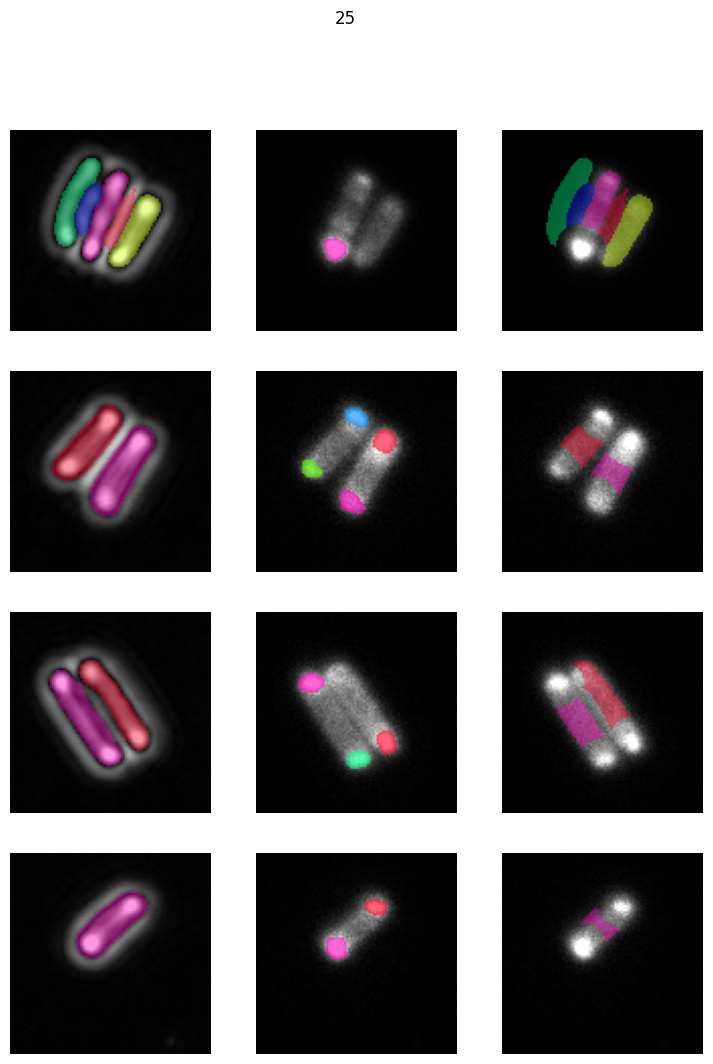

In [6]:
if overview:
    sample, rows = list(overview.items())[-1]
    fig, axes = plt.subplots(len(rows), 3, figsize=(9, 3 * len(rows)), squeeze=False)
    for row_axes, (base, *overlays) in zip(axes, rows):
        for ax, image in zip(row_axes, overlays):
            ax.imshow(image)
            ax.set_axis_off()
    fig.suptitle(sample)
    plt.show()